In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from tqdm import tqdm
import random
import os
import pywt

In [2]:
# keep plots readable and consistent
plt.style.use('default')
sns.set_palette("husl")

DATA_DIR = Path('../../data')
DATA_FILES_DIR = DATA_DIR / 'data_files' / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_info' / 'data_roster.csv'

In [3]:
labels_df = pd.read_csv(LABELS_FILE, index_col=0)
labels_df.head()

def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42, masked=True):
    """
    Load BEC images and labels from disk.
    
    Args:
        data_dir: Path to data_files folder
        labels_df: DataFrame with labels indexed by file path
        max_samples: Maximum number of samples to load (None = all)
        shuffle_seed: Random seed for shuffling
    
    Returns:
        images: array of shape (N, 132, 164, 1)
        labels: array of shape (N,) with integer labels
        positions: list of position lists
        file_paths: list of file paths
    """
    # Discover available class folders dynamically (class-0, class-1, ..., class-9)
    class_dirs = [d for d in data_dir.glob('class-*') if d.is_dir()]

    def class_sort_key(path_obj):
        suffix = path_obj.name.split('-')[-1]
        return int(suffix) if suffix.isdigit() else suffix

    class_dirs = sorted(class_dirs, key=class_sort_key)
    print(f"Discovered class folders: {[d.name for d in class_dirs]}")

    all_files = []
    for class_dir in class_dirs:
        all_files.extend(sorted(class_dir.glob('*.npy')))
    
    print(f"Found {len(all_files)} .npy files")
    
    # Shuffle if requested
    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(all_files)
    
    # Limit samples
    if max_samples is not None:
        all_files = all_files[:max_samples]
    
    images = []
    labels = []
    positions = []
    file_paths = []
    
    print(f"Loading {len(all_files)} samples...")
    for file_path in tqdm(all_files):
        try:
            # load each image bundle
            data_dict = np.load(file_path, allow_pickle=True).item()
            
            # this field is the actual normalized image
            if masked:
                img = data_dict['masked_data'].reshape(132, 164, 1)
            else:
                img = data_dict['cloud_data'].reshape(132, 154, 1)
            
            # match file path to roster index
            # roster uses '/data/data_files/class-x/filename.npy'
            rel_path = '/data/' + '/'.join(file_path.parts[-3:])  # use tail path pieces for roster lookup
            
            if rel_path in labels_df.index:
                label_row = labels_df.loc[rel_path]
                label = label_row['label_v3']
                
                # parse excitation positions from the csv string field
                pos_str = label_row['excitation_position']
                if pd.isna(pos_str) or pos_str == '':
                    pos = []
                else:
                    try:
                        pos = eval(pos_str) if isinstance(pos_str, str) else []
                        if not isinstance(pos, list):
                            pos = [pos] if pos else []
                    except:
                        pos = []
                
                images.append(img)
                labels.append(int(label))
                positions.append(pos)
                file_paths.append(str(file_path))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue
    
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    
    print(f"\nLoaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Label distribution: {np.bincount(labels)}")
    
    return images, labels, positions, file_paths

In [4]:
images, labels, positions, file_paths = load_bec_dataset(
    DATA_FILES_DIR,
    labels_df,
    max_samples=None,
    shuffle_seed=42,
    masked=True
)

Discovered class folders: ['class-0', 'class-1', 'class-2', 'class-8', 'class-9']
Found 16478 .npy files
Loading 16478 samples...


100%|██████████| 16478/16478 [09:08<00:00, 30.01it/s] 



Loaded 16478 images
Image shape: (16478, 132, 164, 1)
Label distribution: [ 1130  3212  1036     0     0     0     0     0   879 10221]


In [5]:
labels_df['label_source'] = 'soldet'
labels_df.iloc[:6257, labels_df.columns.get_loc('label_source')] = 'human'

# Now you can count human vs soldet per class
counts = labels_df.groupby(['label_v3', 'label_source']).size().unstack(fill_value=0)

print(counts)

label_source  human  soldet
label_v3                   
0              1130       0
1              3212       0
2              1036       0
8               879       0
9                 0   10221


In [6]:
# !pip install pywt

In [7]:
# Select only human-labeled no-soliton images
no_soliton_files = [fp for fp, lv in zip(file_paths, labels) if lv == 0]

HH_coeffs = []

for file_path in tqdm(no_soliton_files):
    data_dict = np.load(file_path, allow_pickle=True).item()
    img = data_dict['cloud_data'].astype(np.float32)

    # 1-level DWT
    LL, (LH, HL, HH) = pywt.dwt2(img, 'db1')

    # Flatten HH and append
    HH_coeffs.append(HH.flatten())

HH_all = np.concatenate(HH_coeffs)

# Robust median-based noise estimate
sigma = np.median(np.abs(HH_all)) / 0.6745

print("Estimated noise sigma:", sigma)

100%|██████████| 1130/1130 [00:19<00:00, 58.06it/s] 


Estimated noise sigma: 0.03254384884929728


In [8]:
hf_vals = []

for file_path in tqdm(no_soliton_files):
    data_dict = np.load(file_path, allow_pickle=True).item()
    img = data_dict['masked_data'].astype(np.float32)

    # Compute FFT
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    # High-frequency mask: take outer 25% of frequencies
    h, w = img.shape
    cy, cx = h//2, w//2
    radius = min(cy, cx) // 2
    y, x = np.ogrid[:h, :w]
    mask = ((y - cy)**2 + (x - cx)**2) >= radius**2

    HF = np.fft.ifft2(np.fft.ifftshift(F_shift * mask)).real
    hf_vals.append(HF.flatten())

HF_all = np.concatenate(hf_vals)

sigma_fft = np.std(HF_all)
print("FFT-based high-frequency sigma:", sigma_fft)

100%|██████████| 1130/1130 [00:10<00:00, 110.06it/s]


FFT-based high-frequency sigma: 0.03444954313663834


In [10]:
data_dict = np.load(file_paths[0], allow_pickle=True).item()
print(data_dict.keys())

dict_keys(['cloud_data', 'fitted_parameters', 'rot_angle', 'masked_data', 'imprint_time', 'hold_time'])


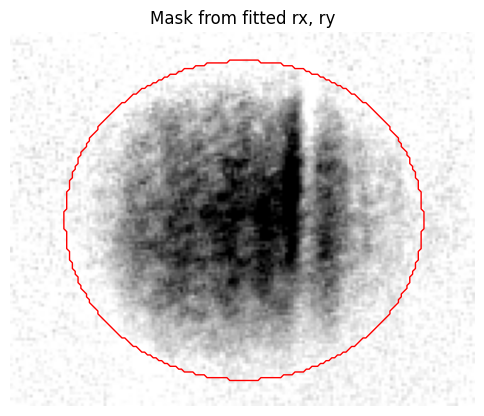

In [19]:
# select image
i = 0
data_dict = np.load(file_paths[i], allow_pickle=True).item()
img = data_dict['cloud_data'].squeeze()
params = data_dict['fitted_parameters']

# full image fitted parameters
rx, ry = params['rx'], params['ry']
cenx, ceny = params['cenx'], params['ceny']

crop_h, crop_w = img.shape

# Meshgrid of cropped image coordinates
y = np.arange(crop_h)
x = np.arange(crop_w)
Xc, Yc = np.meshgrid(x, y)

# Map crop coordinates to full-image frame
Xf = Xc + (cenx - crop_w//2)
Yf = Yc + (ceny - crop_h//2)

# Ellipse equation in full-image coordinates
ellipse_mask = ((Xf - cenx)/rx)**2 + ((Yf - ceny)/ry)**2 <= 1

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray_r', vmin=0, vmax=1)
plt.contour(ellipse_mask, colors='red', linewidths=1)
plt.title("Mask from fitted rx, ry")
plt.axis('off')
plt.show()

In [12]:
HH_coeffs = []

for file_path in tqdm(no_soliton_files):
    data_dict = np.load(file_path, allow_pickle=True).item()
    img = data_dict['cloud_data'].astype(np.float32).squeeze()

    # 1-level DWT on the masked image
    LL, (LH, HL, HH) = pywt.dwt2(img, 'db1')
    HH_coeffs.append(HH.flatten())

HH_all = np.concatenate(HH_coeffs)

# robust median-based noise estimate
sigma_masked = np.median(np.abs(HH_all)) / 0.6745
print("Estimated noise sigma:", sigma_masked)

100%|██████████| 1130/1130 [00:06<00:00, 173.93it/s]


Estimated noise sigma: 0.03254384884929728


In [13]:
hf_vals_masked = []

for file_path in tqdm(no_soliton_files):
    data_dict = np.load(file_path, allow_pickle=True).item()
    img = data_dict['cloud_data'].astype(np.float32).squeeze()
    params = data_dict['fitted_parameters']

    # full image fitted parameters
    rx, ry = params['rx'], params['ry']
    cenx, ceny = params['cenx'], params['ceny']
    crop_h, crop_w = img.shape

    # coordinates
    y = np.arange(crop_h)
    x = np.arange(crop_w)
    Xc, Yc = np.meshgrid(x, y)
    Xf = Xc + (cenx - crop_w//2)
    Yf = Yc + (ceny - crop_h//2)

    # FFT
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    # High-frequency mask: outer 25% of frequencies
    h, w = img.shape
    cy, cx = h//2, w//2
    radius = min(cy, cx)//2
    y_idx, x_idx = np.ogrid[:h, :w]
    hf_filter = ((y_idx - cy)**2 + (x_idx - cx)**2) >= radius**2

    # Inverse FFT of high-freq part
    HF = np.fft.ifft2(np.fft.ifftshift(F_shift * hf_filter)).real

    hf_vals.append(HF.flatten())

HF_all = np.concatenate(hf_vals)
sigma_fft = np.std(HF_all)
print("FFT-based high-frequency sigma (inside mask):", sigma_fft)

100%|██████████| 1130/1130 [00:08<00:00, 125.99it/s]


FFT-based high-frequency sigma (inside mask): 0.03954992288671765


In [14]:
rx_vals = []
ry_vals = []

for file_path in file_paths:
    data_dict = np.load(file_path, allow_pickle=True).item()
    params = data_dict['fitted_parameters']
    rx_vals.append(float(params['rx']))
    ry_vals.append(float(params['ry']))

rx_vals = np.array(rx_vals)
ry_vals = np.array(ry_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].hist(rx_vals, bins=40, color='#1f77b4', edgecolor='white', linewidth=0.6)
axes[0].set_title('Histogram of rx')
axes[0].set_xlabel('rx')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.25)

axes[1].hist(ry_vals, bins=40, color='#ff7f0e', edgecolor='white', linewidth=0.6)
axes[1].set_title('Histogram of ry')
axes[1].set_xlabel('ry')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.25)

plt.show()

print(f'Total files used: {len(file_paths)}')
print(f'rx mean={rx_vals.mean():.3f}, std={rx_vals.std():.3f}')
print(f'ry mean={ry_vals.mean():.3f}, std={ry_vals.std():.3f}')

KeyboardInterrupt: 

In [15]:
# select image
i = 0
data_dict = np.load(file_paths[i], allow_pickle=True).item()
masked_img = data_dict['cloud_data'].squeeze().astype(np.float32)

# Show the full 2D grid of float values (rows x columns)
# Round for readability, while keeping numeric values.
bec_grid = pd.DataFrame(np.round(masked_img, 6)).round(3)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)

print(f"Image index: {i}")
print(f"File: {file_paths[i]}")
print(f"Grid shape: {masked_img.shape}")
print(f"Min={masked_img.min():.6f}, Max={masked_img.max():.6f}")

bec_grid

Image index: 0
File: ..\..\data\data_files\data_files\class-1\2019-08-01_0095_20190523_BEC_F1_NewODT_DMD_12.npy
Grid shape: (132, 164)
Min=-0.219784, Max=1.955661


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163
0,-0.118,0.000,-0.040,-0.046,-0.013,-0.013,-0.155,-0.074,-0.035,-0.032,0.045,-0.067,-0.036,0.007,-0.086,-0.061,-0.048,0.008,-0.103,-0.015,-0.101,-0.033,-0.043,-0.066,0.005,-0.032,0.018,-0.034,-0.102,-0.065,-0.023,0.061,-0.022,-0.079,-0.020,-0.047,0.015,0.088,-0.036,0.007,-0.029,-0.025,-0.056,-0.005,0.008,-0.025,-0.039,-0.015,-0.084,-0.091,-0.014,-0.089,-0.027,0.006,0.003,-0.049,-0.028,-0.116,-0.067,-0.063,0.036,-0.058,-0.078,-0.012,-0.049,-0.025,-0.012,-0.009,0.053,-0.108,-0.110,-0.051,-0.078,0.012,0.031,-0.042,-0.040,-0.010,-0.020,-0.029,-0.003,-0.034,-0.017,-0.050,0.036,-0.077,-0.015,-0.052,0.013,0.003,-0.109,-0.120,-0.037,0.021,0.058,0.043,0.015,0.012,0.010,0.003,-0.016,-0.137,-0.059,0.004,0.005,0.032,-0.085,-0.045,-0.066,0.054,0.036,-0.044,-0.015,0.020,-0.087,-0.013,0.105,-0.075,0.004,-0.015,-0.070,0.019,0.010,-0.060,0.049,0.046,0.054,0.037,-0.061,0.056,0.066,-0.025,-0.005,0.030,0.002,0.023,0.005,-0.027,-0.035,0.006,0.031,-0.064,-0.013,0.026,0.030,0.073,-0.060,0.010,0.078,0.021,-0.113,-0.051,0.047,0.044,-0.039,-0.001,-0.029,-0.019,-0.051,-0.025,-0.083,0.085,0.019,0.004
1,-0.035,-0.055,-0.067,-0.002,0.037,0.002,-0.116,-0.024,-0.044,-0.130,-0.010,-0.054,0.018,0.007,-0.072,-0.093,-0.028,-0.007,-0.074,-0.002,-0.064,0.008,-0.020,-0.082,-0.148,-0.069,-0.036,-0.028,0.044,0.066,0.046,0.021,-0.035,0.006,-0.020,-0.050,-0.017,-0.022,-0.133,-0.005,-0.076,-0.046,-0.040,-0.020,-0.012,-0.062,-0.070,-0.006,-0.009,-0.030,-0.042,-0.097,-0.074,-0.111,-0.053,-0.105,-0.093,-0.111,-0.112,-0.105,-0.103,-0.111,-0.109,-0.046,-0.055,0.037,0.028,-0.049,-0.044,-0.030,-0.032,0.018,0.041,-0.093,-0.002,0.014,-0.018,-0.007,0.009,-0.025,-0.003,-0.053,-0.035,-0.098,0.048,-0.019,-0.078,-0.021,0.034,0.014,0.010,0.063,-0.018,-0.034,-0.026,0.112,0.060,0.041,-0.123,0.005,-0.041,-0.114,-0.033,-0.015,0.000,-0.045,-0.096,0.085,-0.020,0.028,-0.063,-0.026,0.037,0.099,-0.013,-0.001,0.085,0.041,0.063,-0.052,-0.042,-0.074,-0.028,-0.016,0.091,0.001,-0.013,-0.018,-0.020,0.042,0.045,-0.004,0.021,0.010,0.019,0.119,-0.001,0.037,-0.012,-0.063,-0.009,-0.019,0.037,0.019,-0.048,0.011,-0.004,0.081,0.062,-0.042,-0.134,0.014,0.009,-0.016,-0.006,0.047,-0.025,0.033,0.038,-0.003,-0.066,-0.057,-0.049,0.014
2,0.014,-0.045,0.018,0.030,-0.002,0.012,0.032,-0.119,-0.104,-0.039,-0.014,-0.076,-0.060,0.038,0.083,-0.056,-0.013,-0.032,0.015,-0.053,-0.075,-0.031,-0.077,-0.054,-0.053,-0.089,-0.068,-0.097,-0.073,-0.055,-0.036,-0.059,-0.020,0.102,-0.098,-0.052,-0.067,-0.031,-0.062,0.031,0.050,-0.078,-0.081,-0.038,-0.080,-0.035,-0.035,-0.020,0.004,-0.001,-0.035,-0.066,0.010,0.040,-0.100,-0.007,0.048,0.024,-0.037,0.030,-0.062,-0.110,-0.103,-0.033,-0.057,-0.027,0.060,-0.039,-0.086,-0.072,-0.024,-0.044,-0.034,-0.158,-0.096,-0.040,-0.117,-0.120,-0.039,-0.026,-0.013,-0.059,0.025,-0.028,0.082,0.054,-0.099,-0.016,0.030,-0.067,-0.071,-0.042,-0.037,-0.016,-0.011,0.031,-0.118,0.017,-0.061,0.078,0.010,-0.043,-0.055,-0.032,0.075,0.053,0.005,0.089,-0.074,-0.024,-0.090,-0.054,-0.040,0.090,-0.016,-0.003,0.035,0.036,0.018,-0.022,-0.055,-0.049,0.049,-0.055,-0.000,0.046,0.104,0.004,-0.022,-0.069,-0.072,-0.022,-0.006,-0.038,-0.046,-0.025,-0.044,-0.028,-0.018,-0.001,0.040,0.013,0.033,0.011,-0.063,-0.113,-0.072,-0.047,0.015,-0.030,0.017,0.054,-0.004,-0.027,-0.010,0.084,-0.089,0.001,0.029,-0.108,0.049,0.039,0.019,0.008
3,0.046,-0.049,0.094,0.033,-0.128,-0.071,0.022,-0.072,0.068,0.054,0.017,0.018,0.003,0.072,0.080,-0.038,-0.007,-0.051,-0.076,-0.031,0.074,0.017,-0.010,-0.034,0.049,0.006

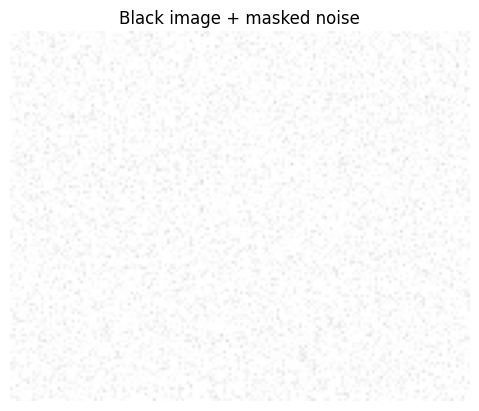

In [16]:
import numpy as np
import matplotlib.pyplot as plt

crop_h, crop_w = 132, 164  # size of masked_data images
sigma_noise = sigma_fft        # wavelet-based masked sigma

# black image
black_img = np.zeros((crop_h, crop_w), dtype=np.float32)

# add Gaussian noise
noise = np.random.normal(0, sigma_noise, size=black_img.shape)
noisy_black = black_img + noise
noisy_black = np.clip(noisy_black, 0, 1)

plt.imshow(noisy_black, cmap='gray_r', vmin=0, vmax=1)
plt.axis('off')
plt.title("Black image + masked noise")
plt.show()